
Columns:
['student_id', 'age', 'gender', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'part_time_job', 'attendance_percentage', 'sleep_hours', 'diet_quality', 'exercise_frequency', 'parental_education_level', 'internet_quality', 'mental_health_rating', 'extracurricular_participation', 'exam_score']


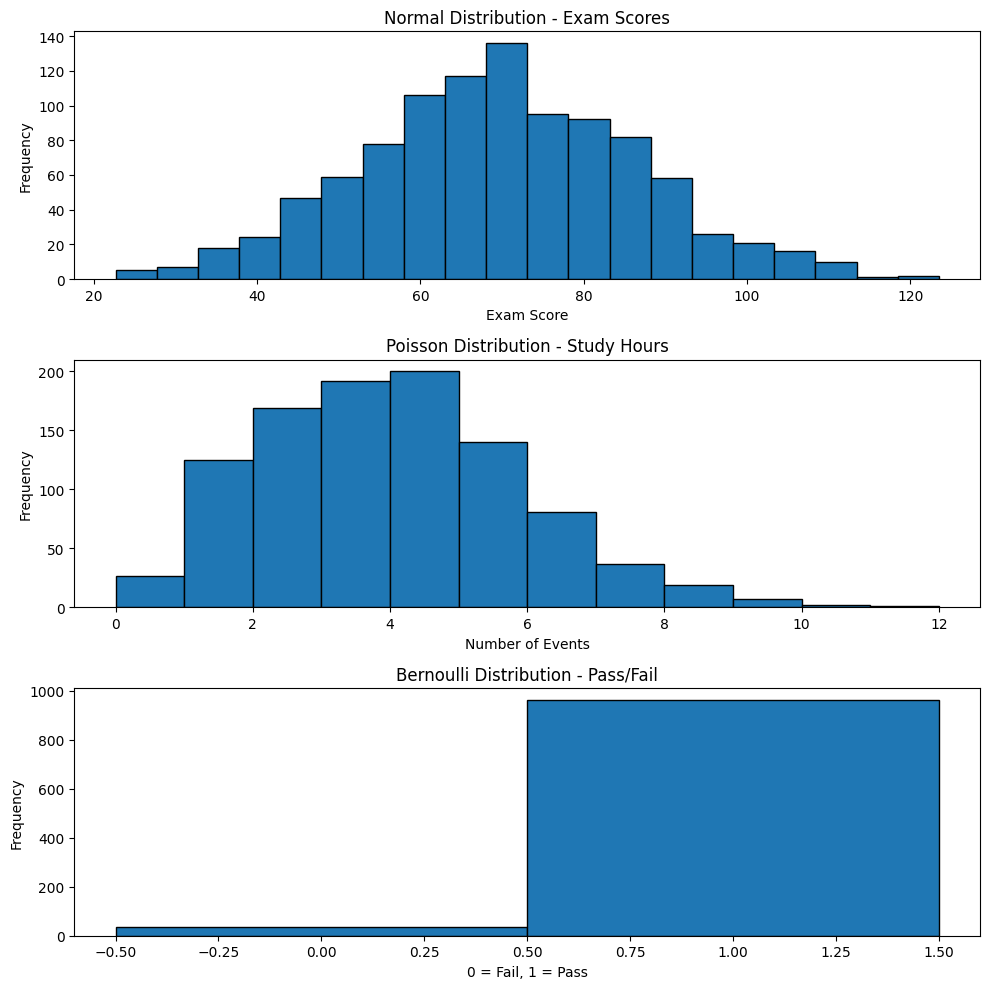


--- Results ---
Mean Exam Score: 69.6015
Standard Deviation: 16.88856392181825
Poisson Lambda: 3.545
Probability of Passing: 0.958

First 10 Normal Samples:
[52.83024778 63.76167432 62.46669317 90.56042607 36.99428434 81.35472662
 79.13461994 73.15221939 89.21641175 76.81679578]

First 10 Poisson Samples:
[6 4 5 2 2 2 6 3 4 1]

First 10 Bernoulli Samples:
[1 1 0 1 1 1 1 1 1 1]


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Kaggle dataset
df = pd.read_csv("Ex-2 student_habits_performance-selected-columns.csv")

# Display column names
print("\nColumns:")
print(df.columns.tolist())

# --------------------------------------------------
# 1. NORMAL DISTRIBUTION
# Using exam_score
# --------------------------------------------------

exam_scores = df["exam_score"].dropna()

mean = exam_scores.mean()
std = exam_scores.std()

normal_data = np.random.normal(
    loc=mean,
    scale=std,
    size=1000
)

# --------------------------------------------------
# 2. POISSON DISTRIBUTION
# Number of students in each group of study hours
# --------------------------------------------------

study_hours = df["study_hours_per_day"].dropna()

# Convert study hours into integer counts
study_hours_count = study_hours.round().astype(int)

lambda_value = study_hours_count.mean()

poisson_data = np.random.poisson(
    lam=lambda_value,
    size=1000
)

# --------------------------------------------------
# 3. BERNOULLI DISTRIBUTION
# Pass / Fail based on exam score
# --------------------------------------------------

# Pass = 1, Fail = 0
pass_fail = (exam_scores >= 40).astype(int)

p = pass_fail.mean()

bernoulli_data = np.random.binomial(
    n=1,
    p=p,
    size=1000
)

# --------------------------------------------------
# VISUALIZATION
# --------------------------------------------------

plt.figure(figsize=(10, 10))

# Normal Distribution
plt.subplot(3, 1, 1)
plt.hist(normal_data, bins=20, edgecolor="black")
plt.title("Normal Distribution - Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Frequency")

# Poisson Distribution
plt.subplot(3, 1, 2)
plt.hist(poisson_data, bins=range(
    poisson_data.min(),
    poisson_data.max() + 2
), edgecolor="black")
plt.title("Poisson Distribution - Study Hours")
plt.xlabel("Number of Events")
plt.ylabel("Frequency")

# Bernoulli Distribution
plt.subplot(3, 1, 3)
plt.hist(
    bernoulli_data,
    bins=[-0.5, 0.5, 1.5],
    edgecolor="black"
)
plt.title("Bernoulli Distribution - Pass/Fail")
plt.xlabel("0 = Fail, 1 = Pass")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# --------------------------------------------------
# OUTPUT
# --------------------------------------------------

print("\n--- Results ---")
print("Mean Exam Score:", mean)
print("Standard Deviation:", std)
print("Poisson Lambda:", lambda_value)
print("Probability of Passing:", p)

print("\nFirst 10 Normal Samples:")
print(normal_data[:10])

print("\nFirst 10 Poisson Samples:")
print(poisson_data[:10])

print("\nFirst 10 Bernoulli Samples:")
print(bernoulli_data[:10])